# Clasificación espacial de coberturas

Este notebook aplica el modelo optimizado sobre el raster reducido para generar mapas clasificados de coberturas.

El proceso incluye:

- carga del modelo optimizado;
- carga del raster reducido;
- clasificación píxel a píxel;
- reconstrucción del mapa clasificado;
- aplicación opcional de filtro de mayoría;
- visualización de mapas;
- exportación de GeoTIFF.

Las salidas corresponden a productos espaciales del flujo de clasificación.


In [1]:
from pathlib import Path
import sys

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml


## Importación de funciones auxiliares

Se utilizan funciones de evaluación para cargar el modelo y construir el mapa de clases.

La clasificación espacial, filtro de mayoría, exportación y visualización se ejecutan desde `inferencia.py`.


In [3]:
from src.clasificacion_coberturas.muestras import cargar_split_clasificacion

from src.clasificacion_coberturas.evaluacion import (
    cargar_modelo,
    obtener_mapa_clases_desde_puntos
)

from src.clasificacion_coberturas.inferencia import pipeline_clasificacion_espacial

## Configuración de rutas

Se definen las rutas del split, modelo optimizado, raster reducido y carpetas de salida.

Para evitar subcarpetas innecesarias, los raster clasificados se guardan directamente en:

`outputs/rasters/clasificacion_coberturas/`


In [4]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

year = 2018

ruta_split = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "splits"
    / f"split_clasificacion_{year}.joblib"
)

ruta_modelo = (
    BASE_DIR
    / "models"
    / "clasificacion_coberturas"
    / "modelo_clasificacion_tuning.joblib"
)

ruta_raster_reducido = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "reducidos"
    / f"S2_REDUCIDO_PEARSON_{year}.tif"
)

carpeta_rasters_salida = (
    BASE_DIR
    / "outputs"
    / "rasters"
    / "clasificacion_coberturas"
)

carpeta_figuras = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "clasificacion_coberturas"
)

print("Split:")
print(ruta_split)

print("\nModelo:")
print(ruta_modelo)

print("\nRaster reducido:")
print(ruta_raster_reducido)

print("\nCarpeta raster de salida:")
print(carpeta_rasters_salida)

print("\nCarpeta figuras:")
print(carpeta_figuras)

Split:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\splits\split_clasificacion_2018.joblib

Modelo:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\models\clasificacion_coberturas\modelo_clasificacion_tuning.joblib

Raster reducido:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\S2_REDUCIDO_PEARSON_2018.tif

Carpeta raster de salida:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\rasters\clasificacion_coberturas

Carpeta figuras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas


## Carga de modelo y metadatos

Se carga el modelo optimizado y la información del split. El mapa de clases se construye a partir de la capa de puntos de entrenamiento.


In [5]:
split_data = cargar_split_clasificacion(ruta_split)

ruta_puntos = Path(split_data["ruta_puntos"])
columna_clase = split_data["columna_clase"]
columna_clase_nombre = split_data["columna_clase_nombre"]
normalizar = split_data["normalizar"]

modelo = cargar_modelo(ruta_modelo)

mapa_clases = obtener_mapa_clases_desde_puntos(
    ruta_puntos=ruta_puntos,
    columna_clase=columna_clase,
    columna_clase_nombre=columna_clase_nombre
)

print("Modelo y metadatos cargados correctamente.")
print("Normalizar raster:", normalizar)
print("Mapa de clases:")
print(mapa_clases)

Modelo y metadatos cargados correctamente.
Normalizar raster: True
Mapa de clases:
{2.0: 'BOSQUES Y AREAS SEMINATURALES', 3.0: 'SUPERFICIES DE AGUA', 5.0: 'TERRITORIOS ARTIFICIALIZADOS'}


## Configuración de clasificación espacial

Se define el nombre base de salida y los parámetros del filtro de mayoría.

El filtro de mayoría suaviza el mapa clasificado reemplazando cada píxel por la clase dominante en una ventana local.


In [6]:
nombre_salida = f"clasificacion_coberturas_{year}"

aplicar_filtro_mayoria = True
majority_size = 3
nodata_salida = 0

print("Nombre de salida:", nombre_salida)
print("Aplicar filtro de mayoría:", aplicar_filtro_mayoria)
print("Tamaño de ventana:", majority_size)
print("NoData:", nodata_salida)

Nombre de salida: clasificacion_coberturas_2018
Aplicar filtro de mayoría: True
Tamaño de ventana: 3
NoData: 0


## Clasificación espacial y exportación

Se aplica el modelo sobre todos los píxeles válidos del raster reducido.

El mapa clasificado y el mapa filtrado se muestran en el notebook y se guardan como:

- GeoTIFF en `outputs/rasters/clasificacion_coberturas/`;
- PNG en `outputs/figures/clasificacion_coberturas/`.


Raster guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\rasters\clasificacion_coberturas\clasificacion_coberturas_2018_clasificado.tif
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\clasificacion_coberturas_2018_clasificado.png


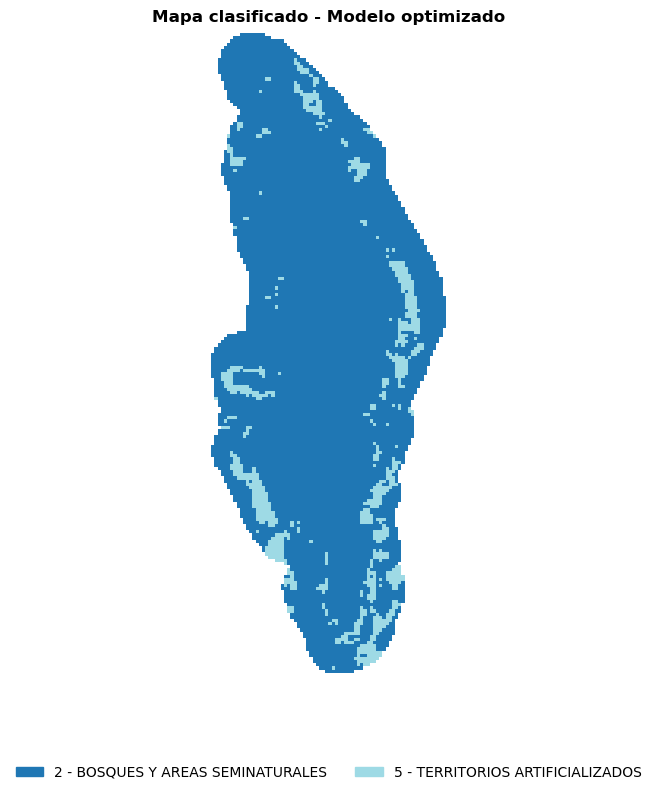

Raster guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\rasters\clasificacion_coberturas\clasificacion_coberturas_2018_clasificado_filtrado.tif
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\clasificacion_coberturas_2018_clasificado_filtrado.png


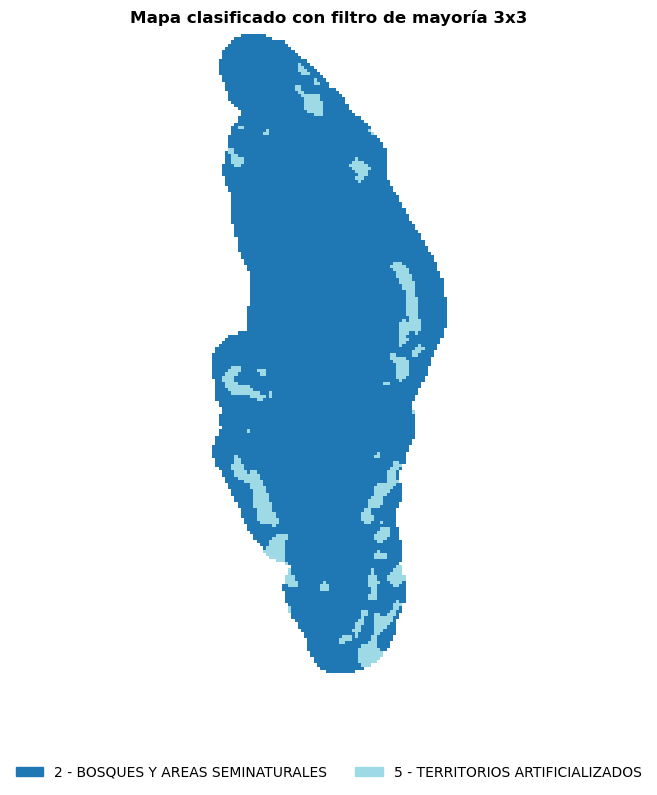

{'mapa_clasificado': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(204, 76), dtype=int16),
 'ruta_mapa_clasificado': WindowsPath('C:/Users/AVDON/JupyterLab/ATENEA/humedales_bogota_ml/outputs/rasters/clasificacion_coberturas/clasificacion_coberturas_2018_clasificado.tif'),
 'mapa_filtrado': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(204, 76), dtype=int16),
 'ruta_mapa_filtrado': WindowsPath('C:/Users/AVDON/JupyterLab/ATENEA/humedales_bogota_ml/outputs/rasters/clasificacion_coberturas/clasificacion_coberturas_2018_clasificado_filtrado.tif')}

In [7]:
resultados_clasificacion = pipeline_clasificacion_espacial(
    modelo=modelo,
    ruta_raster=ruta_raster_reducido,
    carpeta_rasters_salida=carpeta_rasters_salida,
    carpeta_figuras=carpeta_figuras,
    nombre_salida=nombre_salida,
    mapa_clases=mapa_clases,
    normalizar=normalizar,
    aplicar_filtro_mayoria=aplicar_filtro_mayoria,
    majority_size=majority_size,
    nodata_salida=nodata_salida
)

resultados_clasificacion

## Producto de esta etapa

Al finalizar este notebook se generan los mapas espaciales de clasificación de coberturas.

Raster de salida:

`outputs/rasters/clasificacion_coberturas/`

Figuras de salida:

`outputs/figures/clasificacion_coberturas/`

Los mapas generados corresponden a estimaciones espaciales derivadas del modelo optimizado y deben interpretarse junto con las métricas de evaluación del notebook anterior.

## Cierre del flujo

Esta etapa finaliza el flujo principal de clasificación de coberturas.
